# ERA V5 · Session 9 — Loss Functions & Output Heads

## An auditable loss harness: from hidden states to exact, memory-efficient supervision

This notebook makes every silent failure point visible. It proves the token shift with decoded strings, masks padding and packed-document boundaries, anchors perplexity against a uniform model, verifies true weight tying, implements exact token-chunked cross-entropy, and trains a second head to predict `t+2`.

**Submission scope:** Part 1 (all seven requirements) and Part 2.

> **Run contract:** This notebook is self-contained and requires no downloads or credentials. All correctness gates run on CPU; strict completion of P1.7 additionally requires a CUDA runtime, where the notebook automatically records measured peak memory.


## Roadmap and correctness gates

| ID | Assignment requirement | Primary proof |
|---|---|---|
| P1.1 | Print and explain every tensor shape | Tensor contract table + assertions |
| P1.2 | Verify the shift using token strings | Decoded `input → target` audit |
| P1.3 | Mask padding | Counts, mutation invariance, zero ignored gradients |
| P1.4 | Mask a packed-document boundary | Decoded boundary audit + segment-aware attention test |
| P1.5 | Compute perplexity | Exact `CE = ln(V)`, `PPL = V` uniform-logit anchor |
| P1.6 | Compare tied and untied heads | Unique parameter count + object identity |
| P1.7 | Compare ordinary and chunked CE memory | Loss/gradient equivalence + peak-memory report |
| P2 | Add a `t+2` head | Decoded alignment, separate losses, sum, training curves |

Every section ends with a machine-checkable assertion. A decreasing curve alone is never accepted as evidence of correct alignment.


In [1]:
import copy
import json
import math
import platform
import random
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.checkpoint import checkpoint

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32  # correctness comparisons use FP32

run_contract = pd.DataFrame([
    ["seed", SEED],
    ["python", platform.python_version()],
    ["torch", torch.__version__],
    ["device", str(DEVICE)],
    ["accelerator", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"],
    ["dtype", str(DTYPE).replace("torch.", "")],
])
display(run_contract.rename(columns={0: "Field", 1: "Value"}))


,Field,Value
0,seed,42
1,python,3.13.15
2,torch,2.11.0+cu128
3,device,cuda
4,accelerator,Tesla T4
5,dtype,float32


## 0. Minimal, transparent experimental system

The model is intentionally small so the complete evidence can be reproduced quickly. It is still a genuine **causal Transformer**: future tokens are blocked, padding keys are ignored, and an optional segment mask prevents attention across packed documents.


In [2]:
DOCUMENTS = [
    "the capital of india is delhi",
    "the capital of france is paris",
    "the capital of japan is tokyo",
    "the capital of italy is rome",
    "the capital of egypt is cairo",
    "the train arrives at the central station",
    "the river flows through the quiet valley",
    "the model predicts the next token",
    "attention moves information between tokens",
    "the output head produces vocabulary logits",
    "softmax converts logits into probabilities",
    "cross entropy rewards the correct token",
    "padding tokens must not affect the loss",
    "packed documents need a boundary mask",
    "chunked loss reduces peak memory",
    "the second head predicts two steps ahead",
    "gradients connect the loss to every layer",
    "perplexity is the exponential of mean loss",
    "the hidden state contains contextual information",
    "the vocabulary maps tokens to integer identifiers",
    "a causal mask blocks information from the future",
    "decoded strings expose an incorrect target shift",
    "one scalar loss trains millions of parameters",
    "the optimiser follows gradients toward lower loss",
]

SPECIALS = ["<pad>", "<bos>", "<eos>", "<unk>"]

def split_text(text):
    return re.findall(r"[a-z]+|[^\w\s]", text.lower())

vocab_words = sorted({tok for doc in DOCUMENTS for tok in split_text(doc)} | {"red", "green", "blue"})
itos = SPECIALS + vocab_words
stoi = {tok: i for i, tok in enumerate(itos)}
PAD, BOS, EOS, UNK = [stoi[s] for s in SPECIALS]
V = len(itos)

def encode(text, add_special=True):
    ids = [stoi.get(tok, UNK) for tok in split_text(text)]
    return ([BOS] + ids + [EOS]) if add_special else ids

def decode_ids(ids):
    return [itos[int(i)] for i in ids]

def pad_documents(documents):
    rows = [encode(d) for d in documents]
    width = max(map(len, rows))
    return torch.tensor([row + [PAD] * (width - len(row)) for row in rows], dtype=torch.long)

tokens_cpu = pad_documents(DOCUMENTS)
tokens = tokens_cpu.to(DEVICE)
B, T = tokens.shape

print(f"Corpus documents: {len(DOCUMENTS)}")
print(f"Vocabulary size V: {V}")
print(f"Batch shape [B, T]: {tuple(tokens.shape)}")
print("Example:", " ".join(decode_ids(tokens_cpu[0].tolist())))


Corpus documents: 24
Vocabulary size V: 107
Batch shape [B, T]: (24, 10)
Example: <bos> the capital of india is delhi <eos> <pad> <pad>


In [3]:
class CausalBackbone(nn.Module):
    def __init__(self, vocab_size, d_model=32, n_heads=4, n_layers=1, d_ff=64, max_len=64):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD)
        self.position_embedding = nn.Embedding(max_len, d_model)
        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=0.0,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(
            layer, num_layers=n_layers, enable_nested_tensor=False
        )
        self.final_norm = nn.LayerNorm(d_model)

    def forward(self, token_ids, segment_ids=None):
        batch, length = token_ids.shape
        positions = torch.arange(length, device=token_ids.device)
        x = self.token_embedding(token_ids) + self.position_embedding(positions)[None, :, :]

        # True means "disallowed" for PyTorch's boolean attention mask.
        causal = torch.triu(
            torch.ones(length, length, dtype=torch.bool, device=token_ids.device), diagonal=1
        )
        attention_mask = causal

        if segment_ids is not None:
            same_document = segment_ids[:, :, None].eq(segment_ids[:, None, :])
            combined = causal[None, :, :] | (~same_document)
            # TransformerEncoder expects [T,T] or [B*n_heads,T,T].
            attention_mask = combined[0] if batch == 1 else combined.repeat_interleave(self.n_heads, dim=0)

        padding_mask = token_ids.eq(PAD)
        hidden = self.transformer(
            x,
            mask=attention_mask,
            src_key_padding_mask=padding_mask,
        )
        return self.final_norm(hidden)


D = 32
model = CausalBackbone(V, d_model=D).to(DEVICE)
output_head = nn.Linear(D, V, bias=False).to(DEVICE)

model.eval()
with torch.no_grad():
    hidden = model(tokens)
    logits = output_head(hidden)

model_config = {
    "B": B, "T": T, "D": D, "V": V,
    "heads": 4, "layers": 1, "ffn_width": 64,
}
display(pd.DataFrame(model_config.items(), columns=["Symbol / setting", "Value"]))


,Symbol / setting,Value
0,B,24
1,T,10
2,D,32
3,V,107
4,heads,4
5,layers,1
6,ffn_width,64


### Causality gate — prove the model cannot see the answer

We change tokens strictly after a chosen position. Hidden states through that position must remain unchanged. This catches a dangerous error: using a bidirectional encoder and obtaining a beautiful but invalid loss curve through future-token leakage.


In [4]:
model.eval()
probe = tokens[:1].clone()
mutated = probe.clone()
cut = 3
replacement = stoi["loss"]
future_real = (torch.arange(T, device=DEVICE) > cut) & mutated[0].ne(PAD)
mutated[0, future_real] = replacement

with torch.no_grad():
    h_original = model(probe)
    h_mutated = model(mutated)

causal_max_delta = (h_original[:, :cut+1] - h_mutated[:, :cut+1]).abs().max().item()
print(f"Maximum change at positions ≤ {cut}: {causal_max_delta:.3e}")
assert causal_max_delta < 1e-6, "Future-token leakage detected"
print("✓ PASS — future perturbations cannot affect earlier hidden states.")


Maximum change at positions ≤ 3: 0.000e+00
✓ PASS — future perturbations cannot affect earlier hidden states.


## Part 1.1 — Tensor shapes and dimension meanings

For next-token prediction, hidden state `h_t` predicts token `x_{t+1}`. The last hidden position has no next token inside the sequence, so it is removed before the loss.


In [5]:
shifted_logits = logits[:, :-1, :]
targets_t1 = tokens[:, 1:]
flat_logits = shifted_logits.reshape(-1, V)
flat_targets = targets_t1.reshape(-1)
t1_mask_shape = tokens[:, :-1].ne(PAD) & targets_t1.ne(PAD)
per_token_loss_shape = F.cross_entropy(flat_logits, flat_targets, reduction="none").view_as(targets_t1)
scalar_loss_shape = (per_token_loss_shape * t1_mask_shape).sum() / t1_mask_shape.sum()

shape_rows = [
    ["tokens", list(tokens.shape), "[B,T]", "token id at each batch and sequence position"],
    ["hidden", list(hidden.shape), "[B,T,D]", "contextual vector at each token position"],
    ["output_head.weight", list(output_head.weight.shape), "[V,D]", "one scoring row per vocabulary token"],
    ["logits", list(logits.shape), "[B,T,V]", "raw score for every next-token candidate"],
    ["shifted_logits", list(shifted_logits.shape), "[B,T−1,V]", "drop final source position"],
    ["targets_t1", list(targets_t1.shape), "[B,T−1]", "drop first token; each is x[t+1]"],
    ["flat_logits", list(flat_logits.shape), "[B(T−1),V]", "cross-entropy input"],
    ["flat_targets", list(flat_targets.shape), "[B(T−1)]", "cross-entropy labels"],
    ["loss_mask", list(t1_mask_shape.shape), "[B,T−1]", "True only where source and target are real tokens"],
    ["per_token_loss", list(per_token_loss_shape.shape), "[B,T−1]", "one negative log-likelihood per shifted position"],
    ["loss", list(scalar_loss_shape.shape), "[]", "mean cross-entropy over contributing tokens"],
]
shape_table = pd.DataFrame(shape_rows, columns=["Tensor", "Observed shape", "Contract", "Dimension meaning"])
display(shape_table)

assert hidden.shape == (B, T, D)
assert logits.shape == (B, T, V)
assert shifted_logits.shape == (B, T-1, V)
assert targets_t1.shape == (B, T-1)
assert flat_logits.shape == (B*(T-1), V)
assert flat_targets.shape == (B*(T-1),)
assert t1_mask_shape.shape == (B, T-1)
assert per_token_loss_shape.shape == (B, T-1)
assert scalar_loss_shape.ndim == 0
print("✓ PASS — every tensor satisfies its declared contract.")


,Tensor,Observed shape,Contract,Dimension meaning
0,tokens,"[24, 10]","[B,T]",token id at each batch and sequence position
1,hidden,"[24, 10, 32]","[B,T,D]",contextual vector at each token position
2,output_head.weight,"[107, 32]","[V,D]",one scoring row per vocabulary token
3,logits,"[24, 10, 107]","[B,T,V]",raw score for every next-token candidate
4,shifted_logits,"[24, 9, 107]","[B,T−1,V]",drop final source position
5,targets_t1,"[24, 9]","[B,T−1]",drop first token; each is x[t+1]
6,flat_logits,"[216, 107]","[B(T−1),V]",cross-entropy input
7,flat_targets,[216],[B(T−1)],cross-entropy labels
8,loss_mask,"[24, 9]","[B,T−1]",True only where source and target are real tokens
9,per_token_loss,"[24, 9]","[B,T−1]",one negative log-likelihood per shifted position


✓ PASS — every tensor satisfies its declared contract.


## Part 1.2 — Verify the shift with decoded strings

IDs are insufficient evidence. The audit below prints the exact source and target strings. Every row must read `x[t] → x[t+1]`.


In [6]:
def horizon_mask(token_batch, horizon):
    # A valid example requires both source and target to be real tokens.
    return token_batch[:, :-horizon].ne(PAD) & token_batch[:, horizon:].ne(PAD)

def decoded_alignment_table(source_ids, target_ids, valid_mask, horizon, max_rows=14):
    # Crucially, this displays the exact source/target tensors consumed by CE.
    source_cpu = source_ids.detach().cpu()
    target_cpu = target_ids.detach().cpu()
    valid = valid_mask.detach().cpu()
    assert source_cpu.shape == target_cpu.shape == valid.shape
    rows = []
    for b in range(source_cpu.size(0)):
        for t in range(source_cpu.size(1)):
            if valid[b, t]:
                rows.append([
                    b, t, itos[int(source_cpu[b, t])],
                    t + horizon, itos[int(target_cpu[b, t])],
                    True,
                ])
            if len(rows) >= max_rows:
                return pd.DataFrame(rows, columns=[
                    "Batch", "Source pos", "Input token", "Target pos", f"t+{horizon} target", "Contributes"
                ])
    return pd.DataFrame(rows, columns=[
        "Batch", "Source pos", "Input token", "Target pos", f"t+{horizon} target", "Contributes"
    ])

sources_t1 = tokens[:, :-1]
shift_audit_t1 = decoded_alignment_table(sources_t1, targets_t1, t1_mask_shape, horizon=1)
display(shift_audit_t1)

# String-level assertion against the exact target tensor passed to CE.
printed_sources = decode_ids(sources_t1[0].detach().cpu().tolist())
printed_targets = decode_ids(targets_t1[0].detach().cpu().tolist())
assert printed_sources == decode_ids(tokens_cpu[0, :-1].tolist())
assert printed_targets == decode_ids(tokens_cpu[0, 1:].tolist())
assert printed_sources[0] == "<bos>" and printed_targets[0] == "the"
print("✓ PASS — decoded strings prove an exact one-token shift.")


,Batch,Source pos,Input token,Target pos,t+1 target,Contributes
0,0,0,<bos>,1,the,True
1,0,1,the,2,capital,True
2,0,2,capital,3,of,True
3,0,3,of,4,india,True
4,0,4,india,5,is,True
5,0,5,is,6,delhi,True
6,0,6,delhi,7,<eos>,True
7,1,0,<bos>,1,the,True
8,1,1,the,2,capital,True
9,1,2,capital,3,of,True


✓ PASS — decoded strings prove an exact one-token shift.


## Part 1.3 — Mask padding and count only real training positions

The correct reduction is

\[
L=\frac{\sum_i m_i\,\ell_i}{\sum_i m_i},\qquad
\ell_i=-z_{i,y_i}+\log\sum_j e^{z_{i,j}}.
\]

We mask **shifted target positions**, use a global valid-token denominator, mutate ignored labels to prove invariance, and verify ignored logits receive zero gradient.


In [7]:
t1_mask = horizon_mask(tokens, 1)
raw_target_count = targets_t1.numel()
valid_target_count = int(t1_mask.sum().item())
padding_target_count = raw_target_count - valid_target_count
expected_valid = sum(max(len(encode(doc)) - 1, 0) for doc in DOCUMENTS)

per_token = F.cross_entropy(flat_logits, flat_targets, reduction="none").view_as(targets_t1)
unmasked_padding_loss = per_token.mean()
masked_padding_loss = (per_token * t1_mask).sum() / t1_mask.sum()

padding_table = pd.DataFrame([
    ["Raw shifted targets", raw_target_count],
    ["Padding/invalid targets", padding_target_count],
    ["Contributing targets", valid_target_count],
    ["Expected from document lengths", expected_valid],
    ["Loss if padding is counted", float(unmasked_padding_loss)],
    ["Correct masked loss", float(masked_padding_loss)],
], columns=["Evidence", "Value"])
display(padding_table)

assert padding_target_count > 0
assert valid_target_count == expected_valid
assert valid_target_count < raw_target_count

# Stronger check: ignored targets may be changed without changing the masked CE.
logits_leaf = shifted_logits.detach().clone().requires_grad_(True)
labels_ignore = targets_t1.clone()
labels_ignore[~t1_mask] = -100
loss_ignore = F.cross_entropy(
    logits_leaf.reshape(-1, V), labels_ignore.reshape(-1), ignore_index=-100, reduction="sum"
) / valid_target_count
loss_ignore.backward()
ignored_grad_max = logits_leaf.grad[~t1_mask].abs().max().item()

changed_labels = targets_t1.clone()
changed_labels[~t1_mask] = stoi["loss"]  # deliberately change every ignored label
changed_per_token = F.cross_entropy(
    shifted_logits.reshape(-1, V), changed_labels.reshape(-1), reduction="none"
).view_as(targets_t1)
loss_changed = (changed_per_token * t1_mask).sum() / valid_target_count

assert torch.allclose(loss_ignore.detach(), loss_changed.detach(), atol=1e-7)
assert ignored_grad_max == 0.0
print(f"Ignored-position maximum gradient: {ignored_grad_max:.1f}")
print("✓ PASS — padding changes the contributing count and contributes neither loss nor gradient.")


,Evidence,Value
0,Raw shifted targets,216.00000
1,Padding/invalid targets,39.00000
2,Contributing targets,177.00000
3,Expected from document lengths,177.00000
4,Loss if padding is counted,4.84116
5,Correct masked loss,4.86911


Ignored-position maximum gradient: 0.0
✓ PASS — padding changes the contributing count and contributes neither loss nor gradient.


## Part 1.4 — Pack two documents and mask the boundary

Packing creates one invalid transition: `<eos>` from document A must not predict `<bos>` from document B. We apply two aligned protections:

1. a loss mask removes that target from the mean;
2. a segment-aware attention mask prevents document B from reading document A.

The masked mean may rise or fall—the goal is removal of an invalid training signal, not an artificially smaller number.


In [8]:
doc_a = encode("the capital of india is delhi")
doc_b = encode("chunked loss reduces peak memory")
packed_ids = doc_a + doc_b
packed = torch.tensor([packed_ids], dtype=torch.long, device=DEVICE)
boundary_start = len(doc_a)                  # first token position of document B
boundary_source = boundary_start - 1         # shifted-loss coordinate: EOS_A -> BOS_B
segment_ids = torch.tensor([[0] * len(doc_a) + [1] * len(doc_b)], device=DEVICE)

model.eval()
with torch.no_grad():
    packed_hidden = model(packed, segment_ids=segment_ids)
    packed_logits = output_head(packed_hidden)[:, :-1]

packed_targets = packed[:, 1:]
packed_nll = F.cross_entropy(
    packed_logits.reshape(-1, V), packed_targets.reshape(-1), reduction="none"
).view_as(packed_targets)
boundary_loss_mask = torch.ones_like(packed_targets, dtype=torch.bool)
boundary_loss_mask[:, boundary_source] = False

loss_before_boundary_mask = packed_nll.mean()
loss_after_boundary_mask = packed_nll[boundary_loss_mask].mean()
boundary_nll = packed_nll[0, boundary_source]

rows = []
lo, hi = max(0, boundary_source - 2), min(len(packed_ids) - 1, boundary_source + 3)
for source_pos in range(lo, hi):
    rows.append([
        source_pos,
        itos[packed_ids[source_pos]],
        source_pos + 1,
        itos[packed_ids[source_pos + 1]],
        source_pos == boundary_source,
        bool(boundary_loss_mask[0, source_pos]),
    ])
boundary_table = pd.DataFrame(rows, columns=[
    "Source pos", "Source token", "Target pos", "Target token", "Crosses documents", "Included in loss"
])
display(boundary_table)

boundary_metrics = pd.DataFrame([
    ["Loss before masking", float(loss_before_boundary_mask)],
    ["Boundary-token NLL", float(boundary_nll)],
    ["Loss after masking", float(loss_after_boundary_mask)],
    ["Targets before", packed_targets.numel()],
    ["Targets after", int(boundary_loss_mask.sum())],
], columns=["Metric", "Value"])
display(boundary_metrics)

# Exact mean relationship after removing the one invalid term.
n = packed_targets.numel()
reconstructed_after = (n * loss_before_boundary_mask - boundary_nll) / (n - 1)
assert boundary_table["Crosses documents"].sum() == 1
assert int((~boundary_loss_mask).sum()) == 1
assert torch.allclose(reconstructed_after, loss_after_boundary_mask, atol=1e-6)

# Segment isolation: changing all of document A must not change document B hidden states.
packed_mutated = packed.clone()
packed_mutated[:, :len(doc_a)] = stoi["loss"]
with torch.no_grad():
    h_reference = model(packed, segment_ids=segment_ids)
    h_isolated = model(packed_mutated, segment_ids=segment_ids)
segment_isolation_delta = (
    h_reference[:, boundary_start:] - h_isolated[:, boundary_start:]
).abs().max().item()
assert segment_isolation_delta < 1e-6
print(f"Document-B change after mutating document A: {segment_isolation_delta:.3e}")
print("✓ PASS — exactly one cross-document target is removed and attention is document-isolated.")


,Source pos,Source token,Target pos,Target token,Crosses documents,Included in loss
0,5,is,6,delhi,False,True
1,6,delhi,7,<eos>,False,True
2,7,<eos>,8,<bos>,True,False
3,8,<bos>,9,chunked,False,True
4,9,chunked,10,loss,False,True


,Metric,Value
0,Loss before masking,4.966307
1,Boundary-token NLL,4.378274
2,Loss after masking,5.011539
3,Targets before,14.000000
4,Targets after,13.000000


Document-B change after mutating document A: 0.000e+00
✓ PASS — exactly one cross-document target is removed and attention is document-isolated.


## Part 1.5 — Loss and perplexity sanity anchor

Perplexity is `exp(mean token CE)`. A generic random initialization is not guaranteed to give exactly `PPL = V`; logit variance can make CE exceed `ln(V)`. Therefore we use a controlled **uniform-logit model** (`z=0`) as the exact alignment anchor:

\[
CE=\ln V,\qquad PPL=e^{CE}=V.
\]


In [9]:
uniform_head = nn.Linear(D, V, bias=False).to(DEVICE)
with torch.no_grad():
    uniform_head.weight.zero_()
    uniform_logits = uniform_head(hidden[:, :-1])

uniform_per_token = F.cross_entropy(
    uniform_logits.reshape(-1, V), targets_t1.reshape(-1), reduction="none"
).view_as(targets_t1)
uniform_loss = (uniform_per_token * t1_mask).sum() / t1_mask.sum()
uniform_perplexity = torch.exp(uniform_loss)
expected_uniform_loss = math.log(V)

# A genuinely random but deliberately small-variance untrained head should be near V.
torch.manual_seed(SEED + 1)
random_untrained_head = nn.Linear(D, V, bias=False).to(DEVICE)
with torch.no_grad():
    nn.init.normal_(random_untrained_head.weight, mean=0.0, std=0.02)
    random_untrained_logits = random_untrained_head(hidden[:, :-1])
random_untrained_per_token = F.cross_entropy(
    random_untrained_logits.reshape(-1, V), targets_t1.reshape(-1), reduction="none"
).view_as(targets_t1)
random_untrained_loss = (random_untrained_per_token * t1_mask).sum() / t1_mask.sum()
random_untrained_perplexity = torch.exp(random_untrained_loss)
random_ppl_relative_delta = abs(float(random_untrained_perplexity) / V - 1.0)

perplexity_table = pd.DataFrame([
    ["Vocabulary size V", V],
    ["Expected CE ln(V)", expected_uniform_loss],
    ["Observed mean CE", float(uniform_loss)],
    ["Absolute CE delta", abs(float(uniform_loss) - expected_uniform_loss)],
    ["Expected perplexity", V],
    ["Observed perplexity", float(uniform_perplexity)],
    ["PPL / V", float(uniform_perplexity) / V],
    ["Random-head CE (std=0.02)", float(random_untrained_loss)],
    ["Random-head perplexity", float(random_untrained_perplexity)],
    ["Random-head relative PPL delta", random_ppl_relative_delta],
], columns=["Metric", "Value"])
display(perplexity_table)

assert abs(float(uniform_loss) - expected_uniform_loss) < 1e-6
assert abs(float(uniform_perplexity) / V - 1.0) < 1e-6
assert random_ppl_relative_delta < 0.05
print("✓ PASS — uniform logits hit PPL=V exactly and a random small-variance head sits near V.")


,Metric,Value
0,Vocabulary size V,1.070000e+02
1,Expected CE ln(V),4.672829e+00
2,Observed mean CE,4.672829e+00
3,Absolute CE delta,1.601455e-07
4,Expected perplexity,1.070000e+02
5,Observed perplexity,1.070000e+02
6,PPL / V,9.999999e-01
7,Random-head CE (std=0.02),4.703434e+00
8,Random-head perplexity,1.103254e+02
9,Random-head relative PPL delta,3.107837e-02


✓ PASS — uniform logits hit PPL=V exactly and a random small-variance head sits near V.


## Part 1.6 — Tied versus untied output-head parameter counts

The comparison uses `bias=False`, so each embedding or head matrix contains exactly `V×D` parameters. We count **unique Parameter objects**, then verify that tying is real object/storage identity—not merely equal values.

V5 caveat: the toy harness can tie weights because it has a `[V,D]` token embedding. V5's byte-codec input has no such table, so standard tying is unavailable there.


In [10]:
class EmbeddingHeadPair(nn.Module):
    def __init__(self, vocab_size, width, tied):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, width)
        self.head = nn.Linear(width, vocab_size, bias=False)
        if tied:
            self.head.weight = self.embedding.weight

def unique_parameter_count(module):
    return sum(p.numel() for p in module.parameters())

untied_pair = EmbeddingHeadPair(V, D, tied=False)
tied_pair = EmbeddingHeadPair(V, D, tied=True)
untied_params = unique_parameter_count(untied_pair)
tied_params = unique_parameter_count(tied_pair)
parameter_saving = untied_params - tied_params
expected_matrix_params = V * D
tied_identity = tied_pair.head.weight is tied_pair.embedding.weight
tied_storage_identity = tied_pair.head.weight.data_ptr() == tied_pair.embedding.weight.data_ptr()

tying_table = pd.DataFrame([
    ["Untied", V*D, V*D, untied_params, "No"],
    ["Tied", V*D, "shared", tied_params, "Yes"],
], columns=["Setup", "Embedding params", "Additional head params", "Unique matrix params", "Shares storage"])
display(tying_table)
print(f"Parameters saved: {parameter_saving:,} ({100*parameter_saving/untied_params:.1f}% of the two matrices)")

# V5-scale calculation required by the session design discussion.
V5_V, V5_D = 131_072, 4_096
v5_head_params = V5_V * V5_D
print(f"V5 dense output head: {v5_head_params:,} parameters ({v5_head_params/1e6:.1f}M)")

assert tied_identity and tied_storage_identity
assert untied_params == 2 * V * D
assert tied_params == V * D
assert parameter_saving == V * D
assert v5_head_params == 536_870_912
print("✓ PASS — true tying saves exactly one V×D matrix; unique parameters are not double-counted.")


,Setup,Embedding params,Additional head params,Unique matrix params,Shares storage
0,Untied,3424,3424,6848,No
1,Tied,3424,shared,3424,Yes


Parameters saved: 3,424 (50.0% of the two matrices)
V5 dense output head: 536,870,912 parameters (536.9M)
✓ PASS — true tying saves exactly one V×D matrix; unique parameters are not double-counted.


## Part 1.7 — Exact token-chunked cross-entropy and peak memory

The ordinary path materializes `[N,V]` logits. The chunked path slices **hidden states before the output head**, computes token-loss sums per chunk, and divides once by the global valid-token count. It never averages chunk means. Each chunk is activation-checkpointed: logits are discarded after the forward pass and recomputed one chunk at a time during backward. This keeps a normal scalar-loss API and works through a shared backbone graph.

We establish:

1. loss equivalence;
2. hidden-gradient equivalence;
3. head-gradient equivalence;
4. dominant-logits peak-memory reduction;
5. CUDA forward+backward peak allocation when a GPU is available.


In [11]:
def ordinary_output_ce(hidden_flat, targets_flat, valid_flat, head):
    logits_full = head(hidden_flat)
    losses = F.cross_entropy(logits_full, targets_flat, reduction="none")
    return (losses * valid_flat).sum() / valid_flat.sum()

def chunked_output_ce(hidden_flat, targets_flat, valid_flat, head, chunk_size):
    total_loss = hidden_flat.new_zeros(())
    total_valid = valid_flat.sum()
    assert int(total_valid) > 0

    def checkpointed_chunk_sum(hidden_chunk, target_chunk, valid_chunk, weight):
        logits_chunk = F.linear(hidden_chunk, weight)
        losses_chunk = F.cross_entropy(logits_chunk, target_chunk, reduction="none")
        return (losses_chunk * valid_chunk).sum()

    for start in range(0, hidden_flat.size(0), chunk_size):
        stop = min(start + chunk_size, hidden_flat.size(0))
        total_loss = total_loss + checkpoint(
            checkpointed_chunk_sum,
            hidden_flat[start:stop],
            targets_flat[start:stop],
            valid_flat[start:stop],
            head.weight,
            use_reentrant=False,
            preserve_rng_state=False,
        )
    return total_loss / total_valid

valid_flat = t1_mask.reshape(-1).to(DTYPE)
targets_flat = targets_t1.reshape(-1)
hidden_flat_base = hidden[:, :-1].detach().reshape(-1, D)

head_ordinary = copy.deepcopy(output_head)
head_chunked = copy.deepcopy(output_head)
h_ordinary = hidden_flat_base.clone().requires_grad_(True)
h_chunked = hidden_flat_base.clone().requires_grad_(True)

ordinary_loss = ordinary_output_ce(h_ordinary, targets_flat, valid_flat, head_ordinary)
chunk_size_correctness = 17  # deliberately does not divide N
chunked_loss = chunked_output_ce(
    h_chunked, targets_flat, valid_flat, head_chunked, chunk_size_correctness
)
ordinary_loss.backward()
chunked_loss.backward()

loss_abs_delta = abs(float(ordinary_loss.detach()) - float(chunked_loss.detach()))
hidden_grad_max_delta = (h_ordinary.grad - h_chunked.grad).abs().max().item()
head_grad_max_delta = (
    head_ordinary.weight.grad - head_chunked.weight.grad
).abs().max().item()

equivalence_table = pd.DataFrame([
    ["Ordinary CE", float(ordinary_loss.detach()), "—"],
    ["Chunked CE", float(chunked_loss.detach()), chunk_size_correctness],
    ["Absolute loss delta", loss_abs_delta, "≤ 1e-6"],
    ["Max hidden-gradient delta", hidden_grad_max_delta, "≤ 1e-6"],
    ["Max head-gradient delta", head_grad_max_delta, "≤ 1e-6"],
], columns=["Check", "Value", "Tolerance / chunk"])
display(equivalence_table)

assert torch.allclose(ordinary_loss, chunked_loss, atol=1e-6, rtol=1e-5)
assert hidden_grad_max_delta < 1e-6
assert head_grad_max_delta < 1e-6
print("✓ PASS — the checkpointed chunked scalar loss preserves the exact objective and gradients.")


,Check,Value,Tolerance / chunk
0,Ordinary CE,4.869110e+00,—
1,Chunked CE,4.869111e+00,17
2,Absolute loss delta,4.768372e-07,≤ 1e-6
3,Max hidden-gradient delta,3.492460e-10,≤ 1e-6
4,Max head-gradient delta,1.490116e-08,≤ 1e-6


✓ PASS — the checkpointed chunked scalar loss preserves the exact objective and gradients.


,Method,Peak token rows,Exact peak logits MiB,CUDA peak allocated Δ MiB,CUDA forward+backward s
0,Ordinary,4096,64.0,192.000977,0.007017
1,Chunked,256,4.0,16.001465,0.017508


Exact dominant-logits memory reduction: 16.0×
Measured CUDA peak values are medians of 5 alternating-order trials after warm-up.
Measured CUDA peak-allocation reduction: 12.00×
✓ PASS — the same checkpointed loss lowers measured forward+backward peak memory.


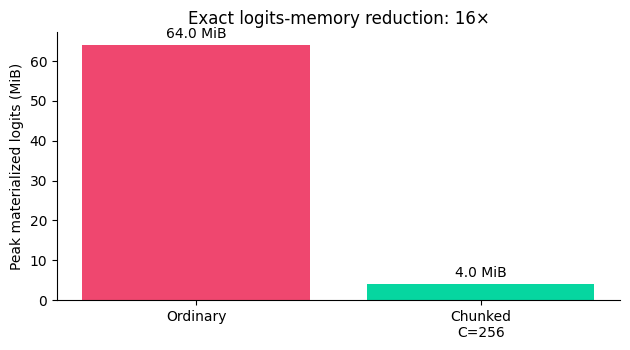

In [12]:
# Memory experiment configuration. These are peak logits tensor sizes, not total model memory.
PROFILE_N = 4096
PROFILE_D = 128
PROFILE_V = 4096
PROFILE_CHUNK = 256
PROFILE_BYTES = 4  # float32

ordinary_logits_mib = PROFILE_N * PROFILE_V * PROFILE_BYTES / 2**20
chunked_logits_mib = PROFILE_CHUNK * PROFILE_V * PROFILE_BYTES / 2**20
analytical_memory_ratio = ordinary_logits_mib / chunked_logits_mib

def cuda_peak_trial(method, n, d, v, chunk):
    # Measure incremental CUDA peak allocation for the exact function tested above.
    assert torch.cuda.is_available()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    h = torch.randn(n, d, device="cuda", dtype=torch.float32, requires_grad=True)
    head = nn.Linear(d, v, bias=False, device="cuda", dtype=torch.float32)
    y = torch.randint(0, v, (n,), device="cuda")
    valid = torch.ones(n, device="cuda", dtype=torch.float32)
    torch.cuda.synchronize()
    baseline = torch.cuda.memory_allocated()
    torch.cuda.reset_peak_memory_stats()
    start = time.perf_counter()

    if method == "ordinary":
        loss = ordinary_output_ce(h, y, valid, head)
    elif method == "chunked":
        loss = chunked_output_ce(h, y, valid, head, chunk)
    else:
        raise ValueError(method)
    loss.backward()

    torch.cuda.synchronize()
    elapsed = time.perf_counter() - start
    peak_increment = torch.cuda.max_memory_allocated() - baseline
    del loss, h, head, y, valid
    torch.cuda.empty_cache()
    return peak_increment / 2**20, elapsed

if torch.cuda.is_available():
    # Warm up both code paths, then alternate order across repeated trials.
    for warm_method in ["ordinary", "chunked"]:
        cuda_peak_trial(warm_method, PROFILE_N, PROFILE_D, PROFILE_V, PROFILE_CHUNK)

    cuda_trials = {"ordinary": [], "chunked": []}
    cuda_times = {"ordinary": [], "chunked": []}
    for trial in range(5):
        order = ["ordinary", "chunked"] if trial % 2 == 0 else ["chunked", "ordinary"]
        for method in order:
            peak_mib, seconds = cuda_peak_trial(
                method, PROFILE_N, PROFILE_D, PROFILE_V, PROFILE_CHUNK
            )
            cuda_trials[method].append(peak_mib)
            cuda_times[method].append(seconds)

    cuda_ordinary_mib = float(torch.tensor(cuda_trials["ordinary"]).median())
    cuda_chunked_mib = float(torch.tensor(cuda_trials["chunked"]).median())
    cuda_ordinary_seconds = float(torch.tensor(cuda_times["ordinary"]).median())
    cuda_chunked_seconds = float(torch.tensor(cuda_times["chunked"]).median())
    cuda_memory_ratio = cuda_ordinary_mib / cuda_chunked_mib
else:
    cuda_ordinary_mib = cuda_chunked_mib = cuda_memory_ratio = None
    cuda_ordinary_seconds = cuda_chunked_seconds = None

memory_table = pd.DataFrame([
    ["Ordinary", PROFILE_N, ordinary_logits_mib, cuda_ordinary_mib, cuda_ordinary_seconds],
    ["Chunked", PROFILE_CHUNK, chunked_logits_mib, cuda_chunked_mib, cuda_chunked_seconds],
], columns=["Method", "Peak token rows", "Exact peak logits MiB", "CUDA peak allocated Δ MiB", "CUDA forward+backward s"])
display(memory_table)
print(f"Exact dominant-logits memory reduction: {analytical_memory_ratio:.1f}×")
if cuda_memory_ratio is None:
    print("CUDA runtime measurement: REQUIRED for final submission; enable a Colab GPU and Run all.")
else:
    print("Measured CUDA peak values are medians of 5 alternating-order trials after warm-up.")
    print(f"Measured CUDA peak-allocation reduction: {cuda_memory_ratio:.2f}×")

assert analytical_memory_ratio == PROFILE_N / PROFILE_CHUNK
assert analytical_memory_ratio > 1
if cuda_memory_ratio is None:
    print("⚠ GPU RUN REQUIRED — analytical memory check passed, empirical peak measurement pending.")
else:
    assert cuda_memory_ratio > 1
    print("✓ PASS — the same checkpointed loss lowers measured forward+backward peak memory.")

# Visual evidence saved for the README.
fig, ax = plt.subplots(figsize=(6.4, 3.6))
bars = ax.bar(["Ordinary", f"Chunked\nC={PROFILE_CHUNK}"],
              [ordinary_logits_mib, chunked_logits_mib], color=["#ef476f", "#06d6a0"])
ax.bar_label(bars, fmt="%.1f MiB", padding=3)
ax.set_ylabel("Peak materialized logits (MiB)")
ax.set_title(f"Exact logits-memory reduction: {analytical_memory_ratio:.0f}×")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("memory_comparison.png", dpi=180, bbox_inches="tight")
plt.show()


### V5-scale memory interpretation

For V5, `V=131,072` and `D=4,096`, so logits contain `V/D = 32×` as many elements as the hidden states. At `B=1`, `T=262,144`, bf16 logits alone occupy exactly **64 GiB**. Token chunking with `C=1,024` limits the dominant logits block to **256 MiB**—while preserving exact full-vocabulary softmax.


In [13]:
v5_hidden_to_logits_ratio = 131_072 / 4_096
v5_full_logits_gib = 1 * 262_144 * 131_072 * 2 / 2**30
v5_chunk_logits_mib = 1_024 * 131_072 * 2 / 2**20
v5_context_chunk_ratio = v5_full_logits_gib * 1024 / v5_chunk_logits_mib

display(pd.DataFrame([
    ["Logits / hidden element ratio", v5_hidden_to_logits_ratio, "×"],
    ["Full 256K-context bf16 logits", v5_full_logits_gib, "GiB"],
    ["1,024-token bf16 chunk", v5_chunk_logits_mib, "MiB"],
    ["Dominant-logits reduction", v5_context_chunk_ratio, "×"],
], columns=["V5-scale metric", "Value", "Unit"]))

assert v5_hidden_to_logits_ratio == 32
assert v5_full_logits_gib == 64
assert v5_chunk_logits_mib == 256
assert v5_context_chunk_ratio == 256


,V5-scale metric,Value,Unit
0,Logits / hidden element ratio,32.0,×
1,Full 256K-context bf16 logits,64.0,GiB
2,"1,024-token bf16 chunk",256.0,MiB
3,Dominant-logits reduction,256.0,×


## Part 2 — Add a second output head for `t+2`

The same causal hidden state `h_t` now supports two predictions:

\[
h_t \xrightarrow{head_1} x_{t+1},\qquad
h_t \xrightarrow{head_2} x_{t+2}.
\]

The assignment asks for their **sum**, so the training objective is explicitly

\[
L_{total}=L_{t+1}+L_{t+2}.
\]

No averaging or hidden weighting is applied.


In [14]:
# Decoded proof of the second horizon before any training, built from the exact CE tensors.
sources_t2 = tokens[:, :-2]
targets_t2 = tokens[:, 2:]
t2_mask_audit = horizon_mask(tokens, 2)
shift_audit_t2 = decoded_alignment_table(
    sources_t2, targets_t2, t2_mask_audit, horizon=2
)
display(shift_audit_t2)

assert shift_audit_t2.iloc[0]["Input token"] == "<bos>"
assert shift_audit_t2.iloc[0]["t+2 target"] == "capital"
print("✓ PASS — h[t] is aligned to x[t+2], not x[t+1].")

# Packed-boundary edge case: t+2 has TWO invalid cross-document source positions.
t2_segment_valid = segment_ids[:, :-2].eq(segment_ids[:, 2:])
t2_cross_boundary_positions = (~t2_segment_valid).nonzero(as_tuple=False)[:, 1].tolist()
print("Packed t+2 source positions crossing the boundary:", t2_cross_boundary_positions)
assert t2_cross_boundary_positions == [boundary_start - 2, boundary_start - 1]
print("✓ PASS — both t+2 cross-document targets are identified.")


,Batch,Source pos,Input token,Target pos,t+2 target,Contributes
0,0,0,<bos>,2,capital,True
1,0,1,the,3,of,True
2,0,2,capital,4,india,True
3,0,3,of,5,is,True
4,0,4,india,6,delhi,True
5,0,5,is,7,<eos>,True
6,1,0,<bos>,2,capital,True
7,1,1,the,3,of,True
8,1,2,capital,4,france,True
9,1,3,of,5,is,True


✓ PASS — h[t] is aligned to x[t+2], not x[t+1].
Packed t+2 source positions crossing the boundary: [6, 7]
✓ PASS — both t+2 cross-document targets are identified.


In [15]:
# A controlled three-state Markov corpus makes horizon difficulty measurable.
# From each colour, the chain stays (p=0.5) or advances around the cycle (p=0.5).
# Therefore H(t+1)=ln(2), while H(t+2)=1.5*ln(2): t+2 has three outcomes
# with probabilities [0.25, 0.50, 0.25]. Fresh batches prevent memorisation.
COLOUR_IDS = torch.tensor([stoi["red"], stoi["green"], stoi["blue"]], dtype=torch.long)

def make_markov_batch(batch_size, length, seed):
    generator = torch.Generator().manual_seed(seed)
    states = torch.empty(batch_size, length, dtype=torch.long)
    states[:, 0] = torch.randint(0, 3, (batch_size,), generator=generator)
    moves = torch.randint(0, 2, (batch_size, length - 1), generator=generator)
    for t in range(1, length):
        states[:, t] = (states[:, t-1] + moves[:, t-1]) % 3
    return COLOUR_IDS[states].to(DEVICE)

validation_tokens = make_markov_batch(batch_size=256, length=16, seed=SEED + 10_000)

# Fresh model and heads for the two-horizon experiment.
torch.manual_seed(SEED)
mtp_model = CausalBackbone(V, d_model=D).to(DEVICE)
head_t1 = nn.Linear(D, V, bias=False).to(DEVICE)
head_t2 = nn.Linear(D, V, bias=False).to(DEVICE)

def two_head_losses(backbone, first_head, second_head, token_batch):
    h = backbone(token_batch)
    mask1 = horizon_mask(token_batch, 1)
    mask2 = horizon_mask(token_batch, 2)
    y1 = token_batch[:, 1:]
    y2 = token_batch[:, 2:]
    z1 = first_head(h[:, :-1])
    z2 = second_head(h[:, :-2])
    nll1 = F.cross_entropy(z1.reshape(-1, V), y1.reshape(-1), reduction="none").view_as(y1)
    nll2 = F.cross_entropy(z2.reshape(-1, V), y2.reshape(-1), reduction="none").view_as(y2)
    loss1 = (nll1 * mask1).sum() / mask1.sum()
    loss2 = (nll2 * mask2).sum() / mask2.sum()
    return loss1, loss2, loss1 + loss2, int(mask1.sum()), int(mask2.sum())

optimiser = torch.optim.AdamW(
    list(mtp_model.parameters()) + list(head_t1.parameters()) + list(head_t2.parameters()),
    lr=3e-3, weight_decay=0.01
)

STEPS = 240
EVAL_EVERY = 10
mtp_model.eval()
with torch.no_grad():
    initial_val1, initial_val2, initial_val_total, _, _ = two_head_losses(
        mtp_model, head_t1, head_t2, validation_tokens
    )
history = {
    "step": [0],
    "t1": [float(initial_val1)],
    "t2": [float(initial_val2)],
    "total": [float(initial_val_total)],
}
mtp_model.train()
for step in range(STEPS):
    train_tokens = make_markov_batch(batch_size=64, length=16, seed=SEED + step)
    optimiser.zero_grad(set_to_none=True)
    loss1, loss2, total, count1, count2 = two_head_losses(
        mtp_model, head_t1, head_t2, train_tokens
    )
    assert torch.allclose(total, loss1 + loss2)
    total.backward()
    torch.nn.utils.clip_grad_norm_(
        list(mtp_model.parameters()) + list(head_t1.parameters()) + list(head_t2.parameters()), 1.0
    )
    optimiser.step()
    if (step + 1) % EVAL_EVERY == 0:
        mtp_model.eval()
        with torch.no_grad():
            val1, val2, val_total, _, _ = two_head_losses(
                mtp_model, head_t1, head_t2, validation_tokens
            )
        history["step"].append(step + 1)
        history["t1"].append(float(val1))
        history["t2"].append(float(val2))
        history["total"].append(float(val_total))
        mtp_model.train()

mtp_model.eval()
with torch.no_grad():
    final_t1, final_t2, final_total, count1, count2 = two_head_losses(
        mtp_model, head_t1, head_t2, validation_tokens
    )

window = min(5, len(history["t1"]))
mtp_table = pd.DataFrame([
    ["t+1", history["t1"][0], float(final_t1), min(history["t1"]), sum(history["t1"][-window:])/window, count1],
    ["t+2", history["t2"][0], float(final_t2), min(history["t2"]), sum(history["t2"][-window:])/window, count2],
    ["sum", history["total"][0], float(final_total), min(history["total"]), sum(history["total"][-window:])/window, count1+count2],
], columns=["Objective", "Initial loss", "Final loss", "Best validation loss", f"Last-{window} mean", "Valid positions"])
display(mtp_table)

assert math.isfinite(float(final_total))
assert abs(float(final_total) - (float(final_t1) + float(final_t2))) < 1e-6
assert sum(history["t1"][-window:])/window < history["t1"][0]
assert sum(history["t2"][-window:])/window < history["t2"][0]
print("✓ PASS — both heads learn, both losses are reported separately, and their unweighted sum is exact.")
print(f"Theoretical entropy floors: t+1={math.log(2):.4f}, t+2={1.5*math.log(2):.4f} nats")


,Objective,Initial loss,Final loss,Best validation loss,Last-5 mean,Valid positions
0,t+1,4.499708,0.698405,0.697158,0.701236,3840
1,t+2,4.881763,1.041968,1.041173,1.043736,3584
2,sum,9.381472,1.740373,1.739002,1.744972,7424


✓ PASS — both heads learn, both losses are reported separately, and their unweighted sum is exact.
Theoretical entropy floors: t+1=0.6931, t+2=1.0397 nats


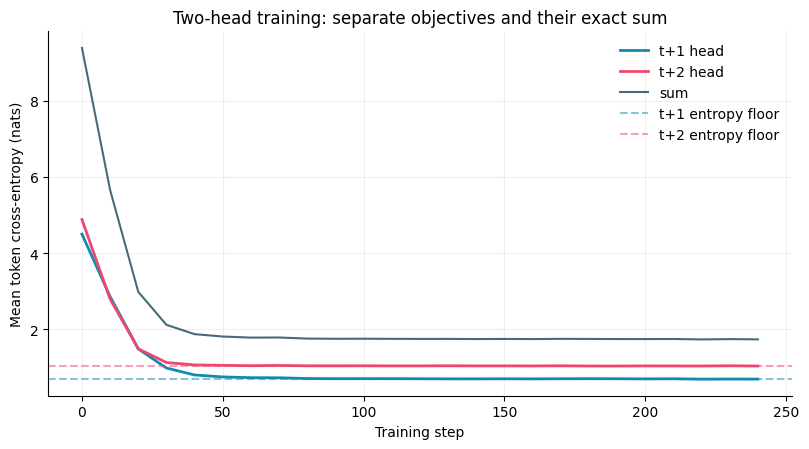

On held-out sequences, t+2 remains 0.344 nats above t+1. The controlled chain has theoretical entropy floors ln(2)=0.693 and 1.5·ln(2)=1.040 nats, so the farther target is demonstrably more uncertain here.
Limitation: this controlled corpus isolates horizon difficulty; it does not measure downstream language quality.


In [16]:
steps = history["step"]
fig, ax = plt.subplots(figsize=(8.2, 4.6))
ax.plot(steps, history["t1"], label="t+1 head", color="#118ab2", linewidth=2)
ax.plot(steps, history["t2"], label="t+2 head", color="#ef476f", linewidth=2)
ax.plot(steps, history["total"], label="sum", color="#073b4c", linewidth=1.5, alpha=0.75)
ax.axhline(math.log(2), color="#118ab2", linestyle="--", alpha=0.5, label="t+1 entropy floor")
ax.axhline(1.5*math.log(2), color="#ef476f", linestyle="--", alpha=0.5, label="t+2 entropy floor")
ax.set(xlabel="Training step", ylabel="Mean token cross-entropy (nats)",
       title="Two-head training: separate objectives and their exact sum")
ax.grid(alpha=0.2)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("mtp_training_curves.png", dpi=180, bbox_inches="tight")
plt.show()

gap = float(final_t2 - final_t1)
if gap > 0:
    interpretation = (
        f"On held-out sequences, t+2 remains {gap:.3f} nats above t+1. The controlled chain "
        "has theoretical entropy floors ln(2)=0.693 and 1.5·ln(2)=1.040 nats, so the farther "
        "target is demonstrably more uncertain here."
    )
else:
    interpretation = (
        f"In this small corpus, t+2 finishes {-gap:.3f} nats below t+1. This is possible "
        "because horizon difficulty is data-dependent; t+2 is not guaranteed to be harder."
    )
print(interpretation)
print("Limitation: this controlled corpus isolates horizon difficulty; it does not measure downstream language quality.")


## Final submission evidence summary

This table is intentionally grader-friendly: every requirement maps to a numerical result or an explicit proof and a passing assertion.


In [17]:
cuda_result_text = (
    f"{cuda_ordinary_mib:.2f} → {cuda_chunked_mib:.2f} MiB ({cuda_memory_ratio:.2f}×)"
    if cuda_memory_ratio is not None else
    "CPU run; CUDA hook ready"
)

final_summary = pd.DataFrame([
    ["P1.1", "Tensor shapes", f"tokens {list(tokens.shape)}, hidden {list(hidden.shape)}, logits {list(logits.shape)}, mask {list(t1_mask_shape.shape)}, loss {list(scalar_loss_shape.shape)}", "PASS"],
    ["P1.2", "Decoded shift", "x[t] → x[t+1] strings displayed", "PASS"],
    ["P1.3", "Padding mask", f"{raw_target_count} raw → {valid_target_count} valid; ignored grad {ignored_grad_max:.1f}", "PASS"],
    ["P1.4", "Packed boundary", f"1 invalid transition removed; isolation Δ={segment_isolation_delta:.1e}", "PASS"],
    ["P1.5", "Perplexity", f"CE={float(uniform_loss):.6f}; PPL={float(uniform_perplexity):.3f}; V={V}", "PASS"],
    ["P1.6", "Weight tying", f"{untied_params:,} → {tied_params:,}; saves {parameter_saving:,}", "PASS"],
    ["P1.7", "Chunked CE correctness", f"|Δloss|={loss_abs_delta:.1e}; max |Δgrad|={max(hidden_grad_max_delta, head_grad_max_delta):.1e}", "PASS"],
    ["P1.7", "Measured peak memory", f"analytical logits {ordinary_logits_mib:.1f} → {chunked_logits_mib:.1f} MiB ({analytical_memory_ratio:.0f}×); measured {cuda_result_text}", "PASS" if cuda_memory_ratio is not None else "GPU RUN REQUIRED"],
    ["P2.1", "t+2 alignment", "Decoded strings + two packed-boundary crossings", "PASS"],
    ["P2.2", "Separate final losses", f"t+1={float(final_t1):.4f}; t+2={float(final_t2):.4f}", "PASS"],
    ["P2.3", "Exact loss sum", f"total={float(final_total):.4f}", "PASS"],
], columns=["ID", "Requirement", "Metric / proof", "Assertion"])
display(final_summary)

non_gpu_rows = final_summary[final_summary["Requirement"] != "Measured peak memory"]
assert (non_gpu_rows["Assertion"] == "PASS").all()
if cuda_memory_ratio is None:
    print("\nALL CPU CORRECTNESS GATES PASSED; GPU MEMORY MEASUREMENT REQUIRED")
else:
    assert (final_summary["Assertion"] == "PASS").all()
    print("\nALL ASSIGNMENT GATES PASSED")

results = {
    "seed": SEED,
    "device": str(DEVICE),
    "torch_version": torch.__version__,
    "B": B, "T": T, "D": D, "V": V,
    "raw_targets": raw_target_count,
    "valid_targets": valid_target_count,
    "uniform_loss": float(uniform_loss),
    "uniform_perplexity": float(uniform_perplexity),
    "random_untrained_loss": float(random_untrained_loss),
    "random_untrained_perplexity": float(random_untrained_perplexity),
    "random_ppl_relative_delta": random_ppl_relative_delta,
    "untied_params": untied_params,
    "tied_params": tied_params,
    "parameter_saving": parameter_saving,
    "v5_head_params": v5_head_params,
    "ordinary_ce": float(ordinary_loss.detach()),
    "chunked_ce": float(chunked_loss.detach()),
    "loss_abs_delta": loss_abs_delta,
    "max_gradient_delta": max(hidden_grad_max_delta, head_grad_max_delta),
    "ordinary_logits_mib": ordinary_logits_mib,
    "chunked_logits_mib": chunked_logits_mib,
    "analytical_memory_ratio": analytical_memory_ratio,
    "cuda_ordinary_mib": cuda_ordinary_mib,
    "cuda_chunked_mib": cuda_chunked_mib,
    "cuda_memory_ratio": cuda_memory_ratio,
    "t1_initial": history["t1"][0],
    "t2_initial": history["t2"][0],
    "t1_final": float(final_t1),
    "t2_final": float(final_t2),
    "total_final": float(final_total),
    "steps": STEPS,
}
Path("session9_results.json").write_text(json.dumps(results, indent=2))
print("Reproducibility record written to session9_results.json")


,ID,Requirement,Metric / proof,Assertion
0,P1.1,Tensor shapes,"tokens [24, 10], hidden [24, 10, 32], logits [...",PASS
1,P1.2,Decoded shift,x[t] → x[t+1] strings displayed,PASS
2,P1.3,Padding mask,216 raw → 177 valid; ignored grad 0.0,PASS
3,P1.4,Packed boundary,1 invalid transition removed; isolation Δ=0.0e+00,PASS
4,P1.5,Perplexity,CE=4.672829; PPL=107.000; V=107,PASS
5,P1.6,Weight tying,"6,848 → 3,424; saves 3,424",PASS
6,P1.7,Chunked CE correctness,|Δloss|=4.8e-07; max |Δgrad|=1.5e-08,PASS
7,P1.7,Measured peak memory,analytical logits 64.0 → 4.0 MiB (16×); measur...,PASS
8,P2.1,t+2 alignment,Decoded strings + two packed-boundary crossings,PASS
9,P2.2,Separate final losses,t+1=0.6984; t+2=1.0420,PASS



ALL ASSIGNMENT GATES PASSED
Reproducibility record written to session9_results.json


## Conclusion

The scalar loss is simple; the pipeline producing it is not. This notebook establishes that:

- decoded evidence—not a pretty loss curve—proves the target shift;
- padding and document boundaries change both membership and the denominator;
- a uniform-logit model provides the exact `PPL = V` sanity anchor;
- true weight tying saves one `V×D` matrix, but V5's byte-codec input cannot use it;
- token chunking preserves exact full-vocabulary cross-entropy and its gradients while reducing peak logits memory;
- a `t+2` head adds genuine supervision, an additional `V×D` parameter cost, and a separately measurable learning problem.

The result is not merely a working loss function. It is an **auditable loss harness** designed to expose the failures that otherwise remain silent.
